In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings(action = 'ignore')

In [15]:
#matplotlib 한글

# 사용할 한글 폰트 지정 - 자기 OS만 # 지우고 쓰기
# font_path = "C:/Windows/Fonts/malgun.ttf"  # Windows
font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"  # macOS
# font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"  # Linux

font_prop = fm.FontProperties(fname=font_path)

# 폰트 적용
plt.rc('font', family=font_prop.get_name())

In [24]:
train = pd.read_csv('csv/train.csv').drop(columns = ['ID'])

In [19]:
from scipy.stats import f_oneway
for feature in ['직원 수']:
    mean_value = train[feature].mean()
    train[feature] = train[feature].fillna(mean_value)
groups = [group['직원 수'].values for name, group in train.groupby('국가')]

# 일원분산분석
stat, p = f_oneway(*groups)

print(f"F 통계량: {stat:.3f}, p-value: {p:.3f}")


F 통계량: 2.718, p-value: 0.004


In [20]:
from scipy.stats import chi2_contingency

# 1. 교차표 (contingency table) 생성
table = pd.crosstab(train['국가'], train['분야'])

# 2. 카이제곱 검정 실행
stat, p, dof, expected = chi2_contingency(table)

print(f"Chi2 통계량: {stat:.3f}, p-value: {p:.3f}")

Chi2 통계량: 118.931, p-value: 0.004


In [21]:
from scipy.stats import chi2_contingency

# 1. 교차표 (contingency table) 생성
table = pd.crosstab(train['국가'], train['투자단계'])

# 2. 카이제곱 검정 실행
stat, p, dof, expected = chi2_contingency(table)

print(f"Chi2 통계량: {stat:.3f}, p-value: {p:.3f}")

Chi2 통계량: 53.791, p-value: 0.029


In [23]:
from scipy.stats import f_oneway
for feature in ['총 투자금(억원)']:
    mean_value = train[feature].mean()
    train[feature] = train[feature].fillna(mean_value)
groups = [group['총 투자금(억원)'].values for name, group in train.groupby('국가')]

# 일원분산분석
stat, p = f_oneway(*groups)

print(f"F 통계량: {stat:.3f}, p-value: {p:.3f}")


F 통계량: 0.706, p-value: 0.704


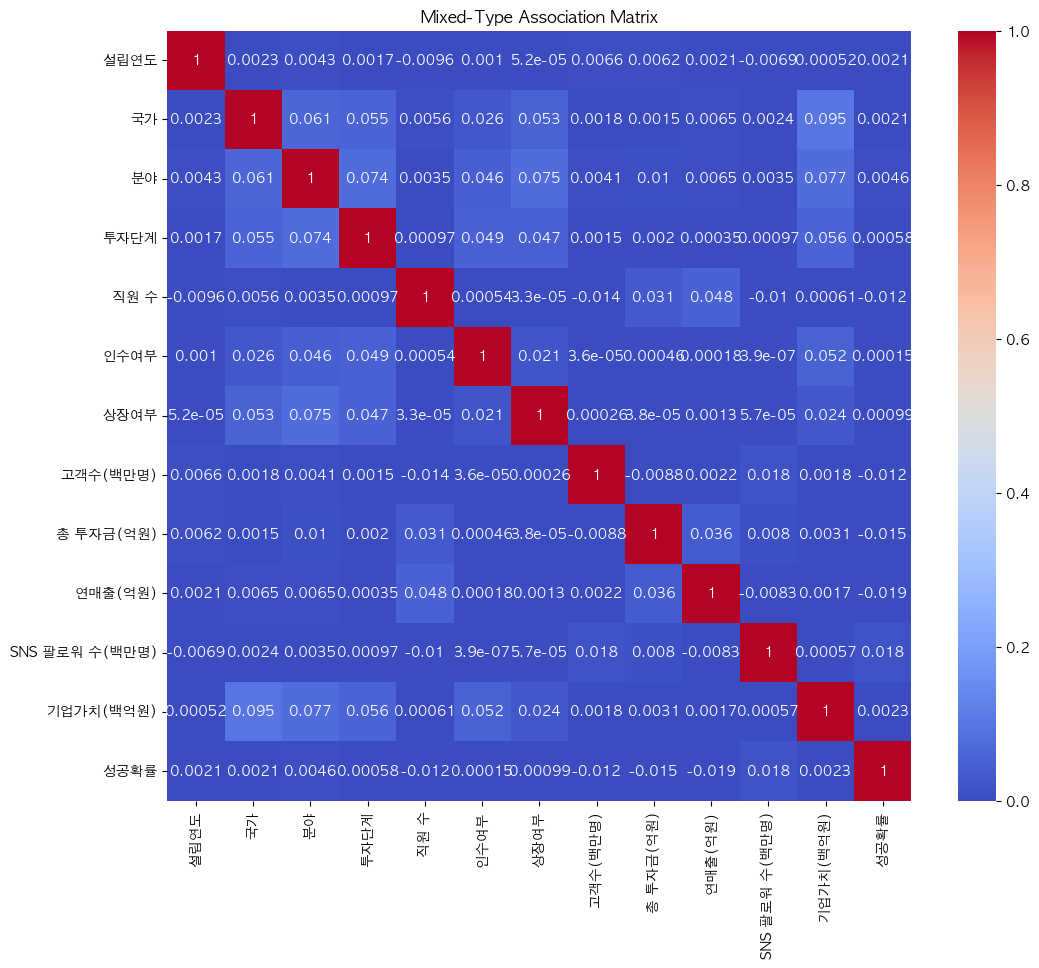

In [26]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else np.nan

def eta_squared(y, x):  # y: 수치형, x: 범주형
    lm = LinearRegression().fit(pd.get_dummies(x, drop_first=True), y)
    y_pred = lm.predict(pd.get_dummies(x, drop_first=True))
    ss_total = np.sum((y - np.mean(y)) ** 2)
    ss_reg = np.sum((y_pred - np.mean(y)) ** 2)
    return ss_reg / ss_total if ss_total > 0 else np.nan

def mixed_assoc_matrix(df):
    cols = df.columns
    assoc_matrix = pd.DataFrame(index=cols, columns=cols)

    for col1 in cols:
        for col2 in cols:
            if col1 == col2:
                assoc_matrix.loc[col1, col2] = 1.0
            else:
                x, y = df[col1], df[col2]

                # 수치형 ↔ 수치형
                if pd.api.types.is_numeric_dtype(x) and pd.api.types.is_numeric_dtype(y):
                    assoc = x.corr(y)

                # 범주형 ↔ 범주형
                elif pd.api.types.is_object_dtype(x) and pd.api.types.is_object_dtype(y):
                    assoc = cramers_v(x, y)

                # 수치형 ↔ 범주형
                elif pd.api.types.is_numeric_dtype(x) and pd.api.types.is_object_dtype(y):
                    assoc = eta_squared(x, y)
                elif pd.api.types.is_object_dtype(x) and pd.api.types.is_numeric_dtype(y):
                    assoc = eta_squared(y, x)

                else:
                    assoc = np.nan

                assoc_matrix.loc[col1, col2] = assoc

    return assoc_matrix.astype(float)

numeric_features = ['직원 수','고객수(백만명)','총 투자금(억원)','연매출(억원)','SNS 팔로워 수(백만명)']
# 수치형 변수 결측치를 평균값으로 대체
for feature in numeric_features:
    mean_value = train[feature].mean()
    train[feature] = train[feature].fillna(mean_value)

assoc_mat = mixed_assoc_matrix(train)

# 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(assoc_mat, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title('Mixed-Type Association Matrix')
plt.show()

In [4]:
features=list(train.columns)
print(features)

['설립연도', '국가', '분야', '투자단계', '직원 수', '인수여부', '상장여부', '고객수(백만명)', '총 투자금(억원)', '연매출(억원)', 'SNS 팔로워 수(백만명)', '기업가치(백억원)', '성공확률']


In [6]:
category_features = ['설립연도','국가','분야','투자단계','기업가치(백억원)']
numeric_features = ['직원 수','고객수(백만명)','총 투자금(억원)','연매출(억원)','SNS 팔로워 수(백만명)']
bool_features = ['인수여부','상장여부']

for cat in category_features:
    print(train[cat].unique())
    
for cat in bool_features:
    print(train[cat].unique())

[2009 2023 2018 2016 2020 2012 2008 2005 2015 2002 2019 2001 2006 2004
 2021 2011 2013 2003 2014 2017 2010 2022 2007]
['CT005' 'CT006' 'CT007' 'CT002' 'CT008' 'CT010' 'CT001' 'CT009' 'CT003'
 'CT004']
['이커머스' '핀테크' '기술' nan '에듀테크' '게임' '헬스케어' '물류' '푸드테크' 'AI' '에너지']
['Series A' 'Seed' 'Series C' 'Series B' 'IPO']
[nan '2500-3500' '3500-4500' '1500-2500' '4500-6000' '6000이상']
['No' 'Yes']
['No' 'Yes']


In [7]:
columns_with_zero = train.columns[(train == 0).any()]

print(columns_with_zero)

Index(['SNS 팔로워 수(백만명)'], dtype='object')


In [76]:
train.count()

설립연도              4376
국가                4376
분야                3519
투자단계              4376
직원 수              4202
인수여부              4376
상장여부              4376
고객수(백만명)          3056
총 투자금(억원)         4376
연매출(억원)           4376
SNS 팔로워 수(백만명)    4376
기업가치(백억원)         3156
성공확률              4376
dtype: int64

In [33]:
# 결측치가 있는 컬럼만 출력
missing_values = train[features].isnull().sum()
print(missing_values[missing_values > 0])

print(-1 in train[numeric_features])

분야            857
직원 수          174
고객수(백만명)     1320
기업가치(백억원)    1220
dtype: int64
False


In [34]:
# 전체 개수 확인
train.count()

설립연도              4376
국가                4376
분야                3519
투자단계              4376
직원 수              4202
인수여부              4376
상장여부              4376
고객수(백만명)          3056
총 투자금(억원)         4376
연매출(억원)           4376
SNS 팔로워 수(백만명)    4376
기업가치(백억원)         3156
성공확률              4376
dtype: int64

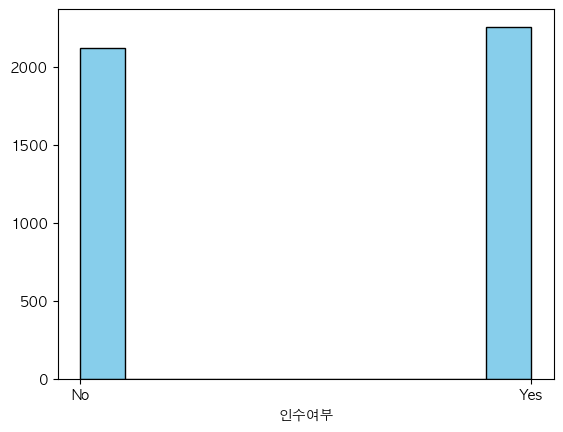

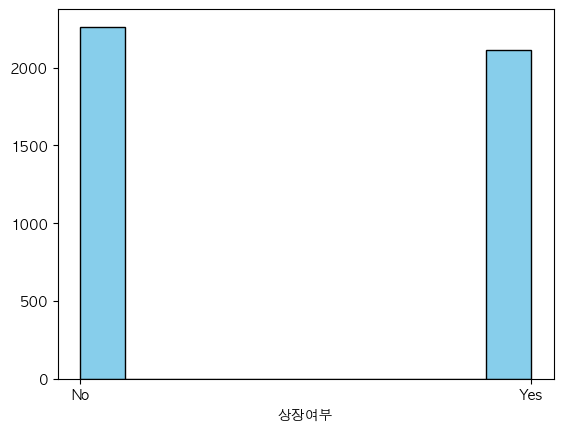

In [75]:
# feature 별 개수 확인 (결측치 제외))

for col in bool_features:
    plt.hist(train[col].dropna(), color='skyblue', edgecolor='black')
    plt.xlabel(f"{col}")

    plt.xticks(fontsize=10)
    plt.show()

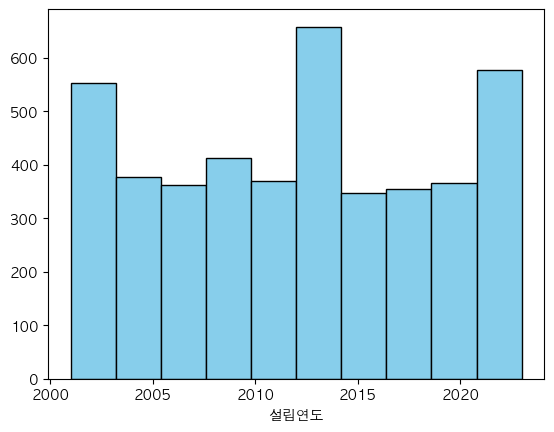

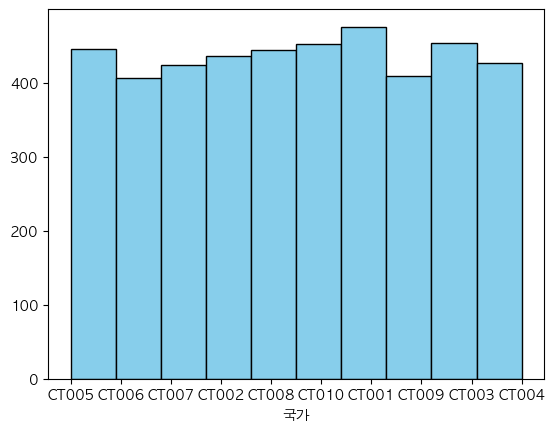

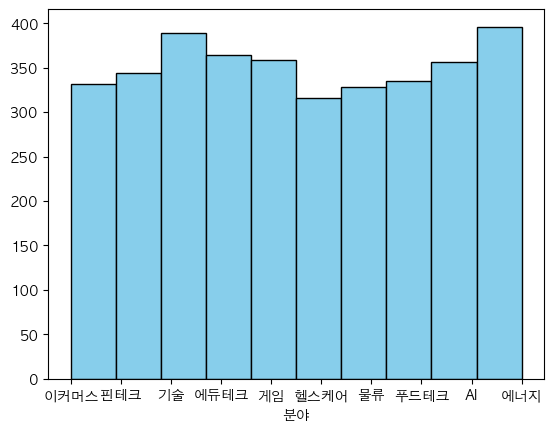

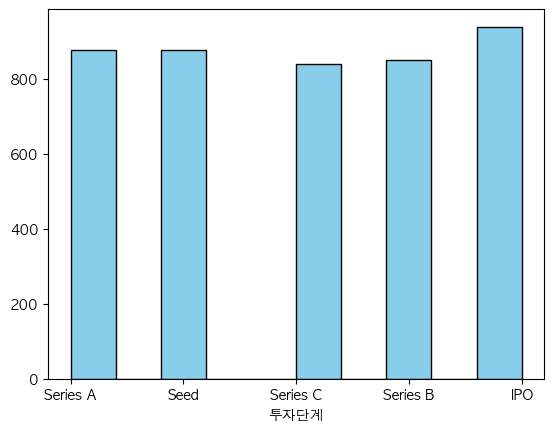

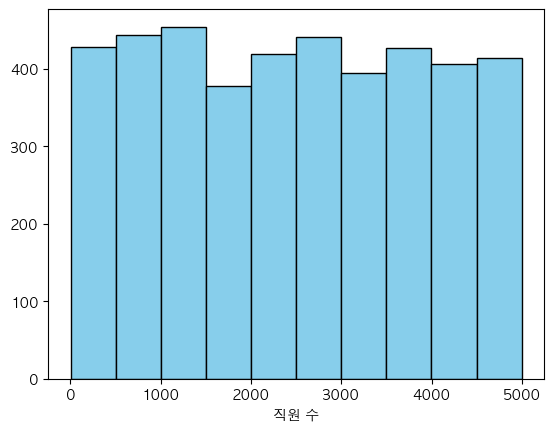

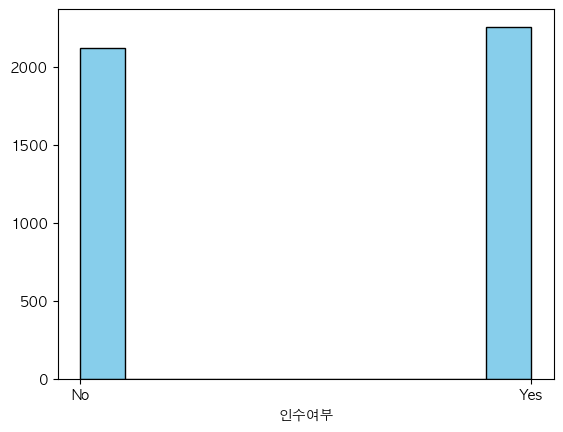

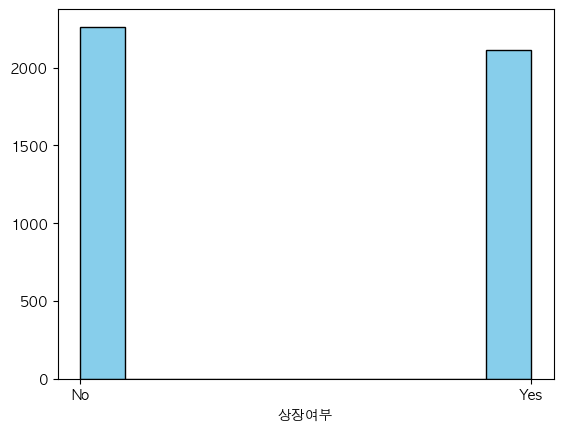

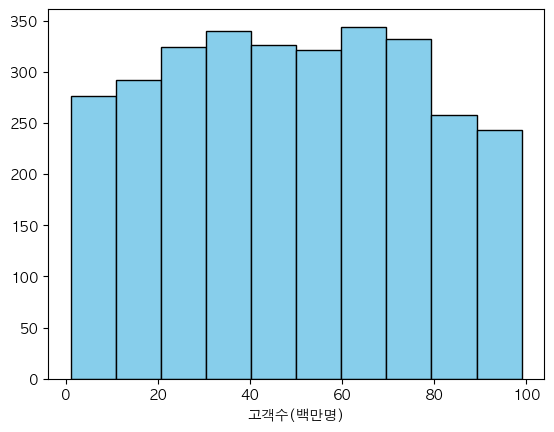

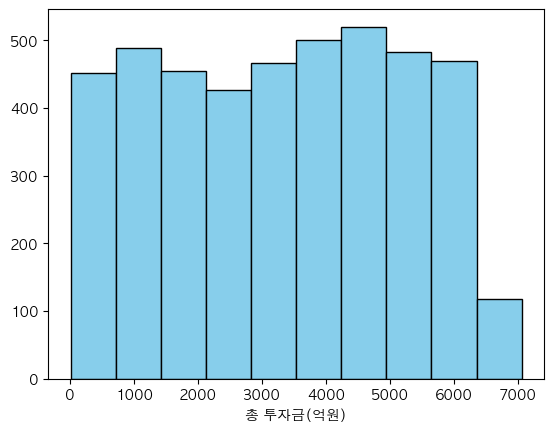

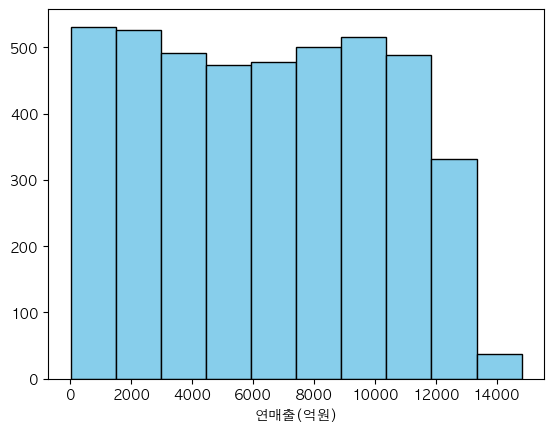

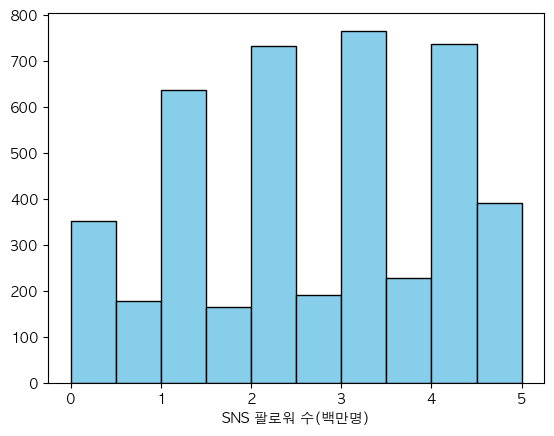

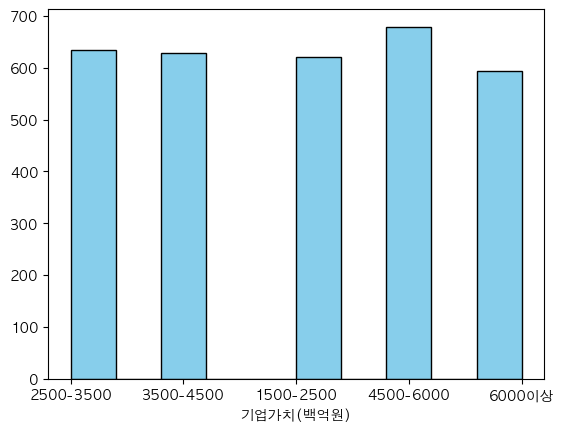

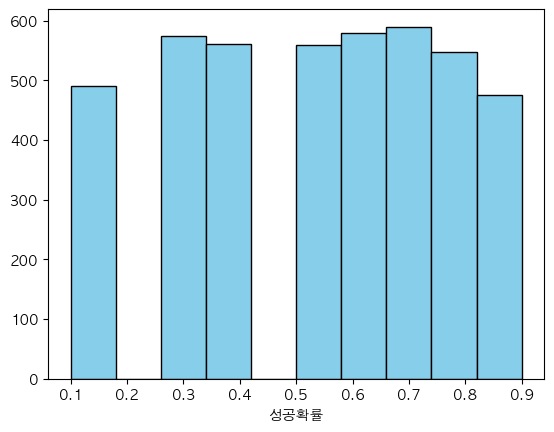

In [35]:
# feature 별 개수 확인 (결측치 제외))

for col in features:
    plt.hist(train[col].dropna(), color='skyblue', edgecolor='black')
    plt.xlabel(f"{col}")

    plt.xticks(fontsize=10)
    plt.show()

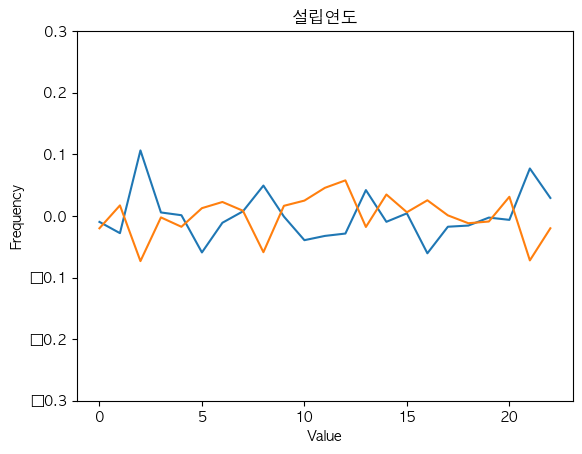

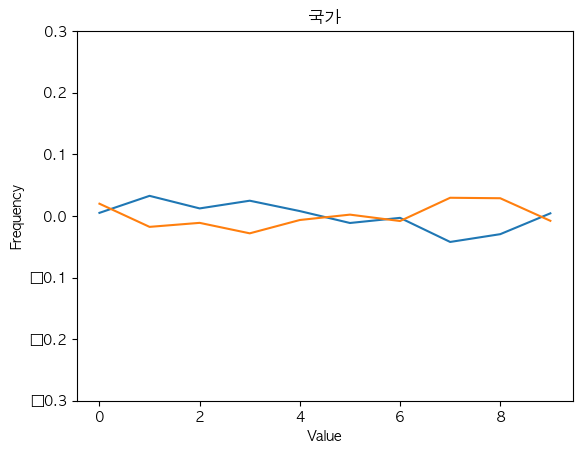

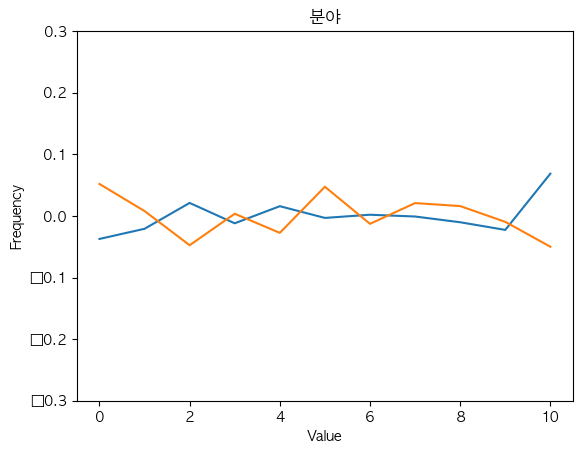

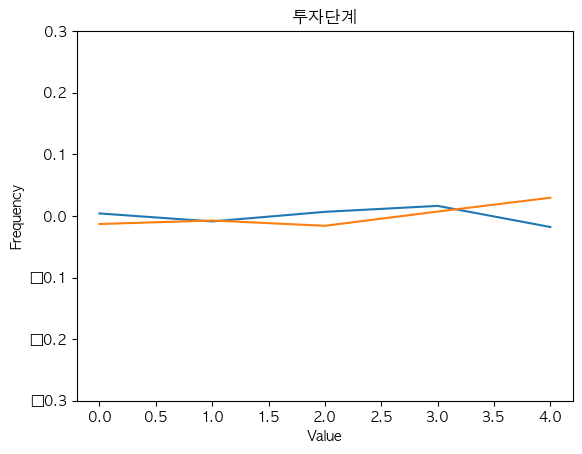

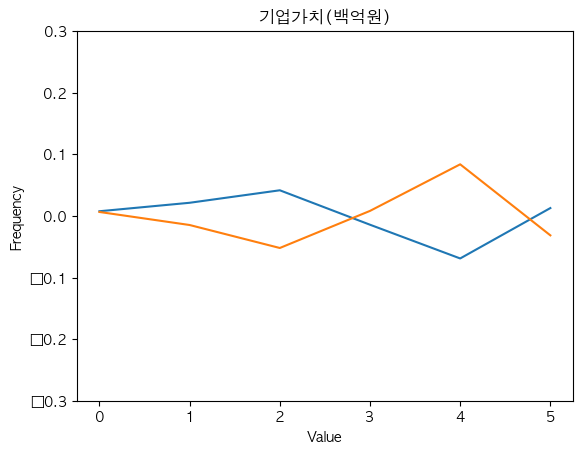

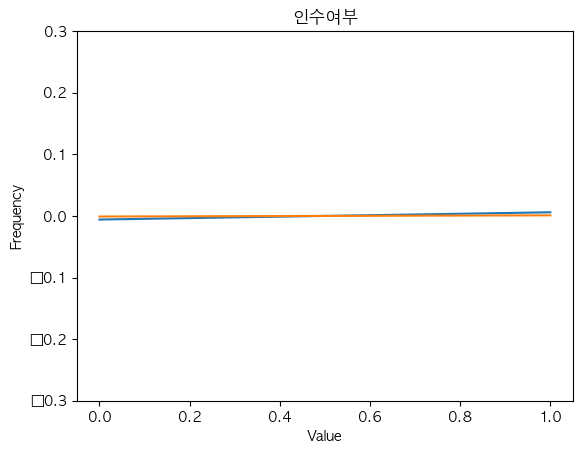

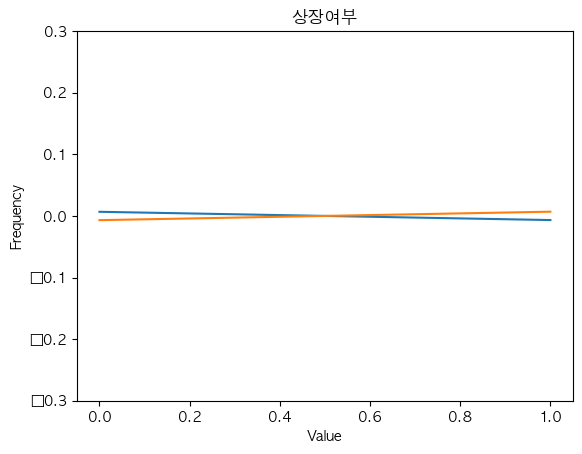

In [69]:
# feature 별 개수 확인 (결측치 제외))

for col in category_features+bool_features:
    train_df=train.copy() #원본 보호
    train_df = train_df.dropna(subset=[col])
    
    count_df = train_df.groupby([col, '성공확률']).size().unstack(fill_value=0)
    count_df = count_df.div(count_df.sum(axis=1), axis=0)

    count_df['[0,0.5)'] = 0
    count_df['[0.5,1]'] = 0
    for percentage in count_df.columns[:-3]:
        if percentage<0.5: count_df['[0,0.5)']+=count_df[percentage]
        else: count_df['[0.5,1]']+=count_df[percentage]
    plt.plot(count_df.index, count_df['[0,0.5)']-count_df['[0,0.5)'].mean(), label=percentage)
    plt.plot(count_df.index, count_df['[0.5,1]']-count_df['[0.5,1]'].mean(), label=percentage)
    
    '''for percentage in count_df.columns[:-1]:  # 마지막은 bin_center
        plt.plot(count_df['bin_center'], count_df[percentage], label=percentage)'''
    
    plt.ylim(-0.3,0.3)
    
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

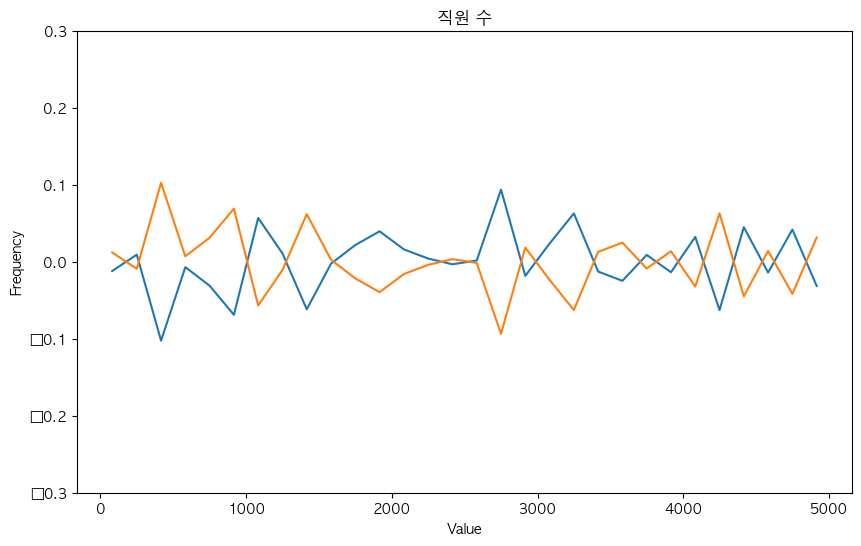

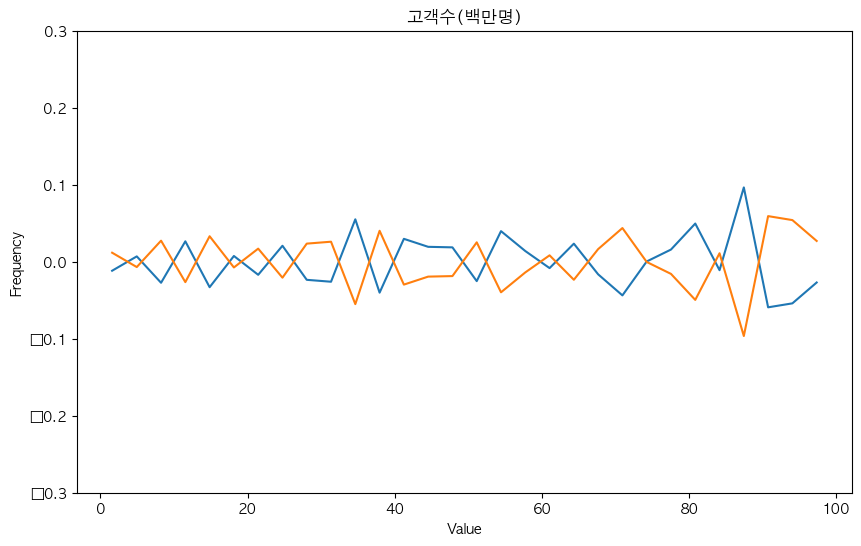

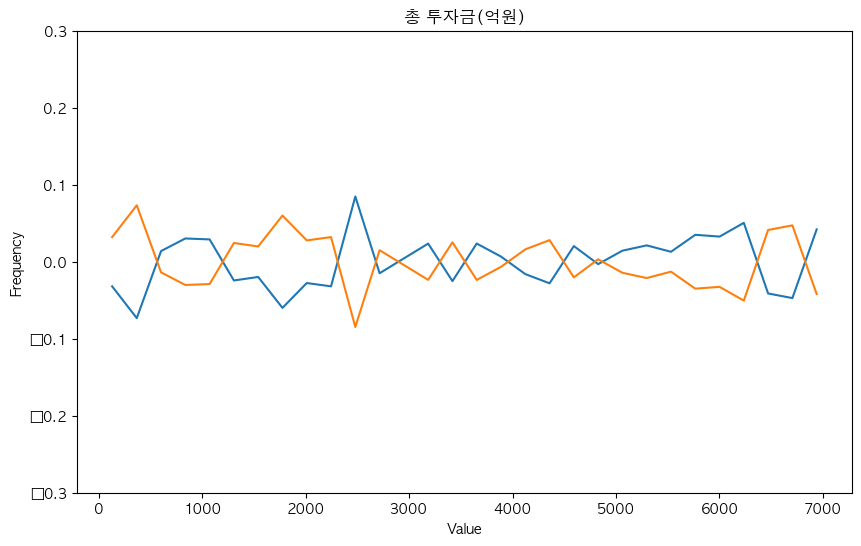

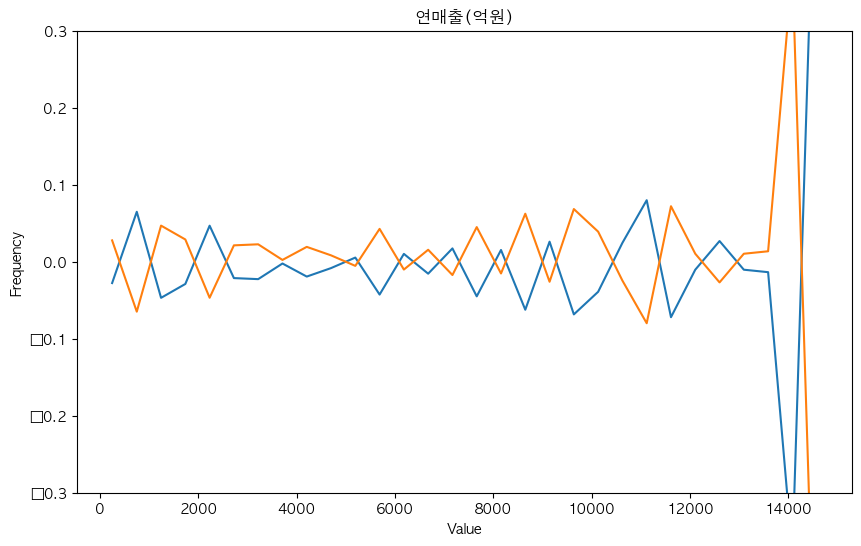

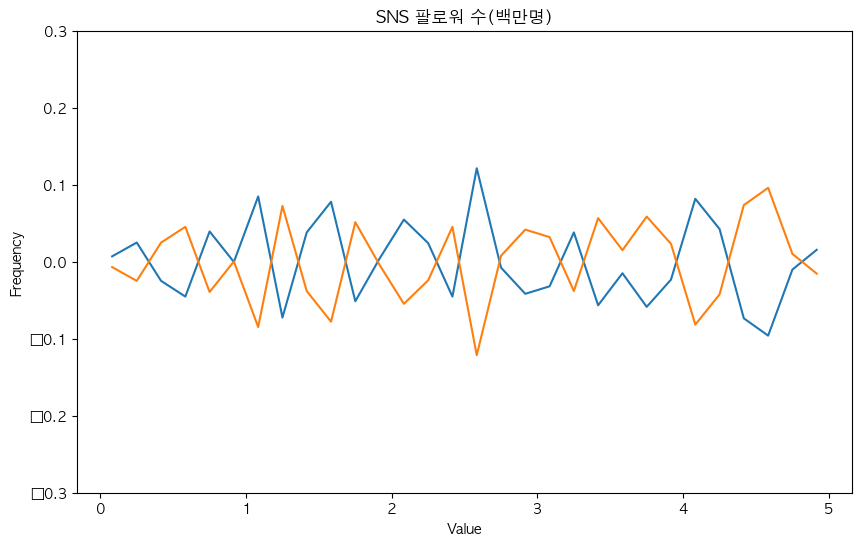

In [70]:
# feature 별 개수 확인 (결측치 제외))

for col in numeric_features:
    train_df=train.copy() #원본 보호
    train_df = train_df.dropna(subset=[col])
    
    train_df['bin']=pd.cut(train_df[col], bins=30)
    
    count_df = train_df.groupby(['bin', '성공확률']).size().unstack(fill_value=0)
    count_df = count_df.div(count_df.sum(axis=1), axis=0)
    
    # 구간 중심값
    count_df['bin_center'] = count_df.index.map(lambda x: x.mid)

    counts, bins = np.histogram(train_df[col], bins=30)
    percent = counts / counts.sum()

    plt.figure(figsize=(10,6))

    count_df['[0,0.5)'] = 0
    count_df['[0.5,1]'] = 0
    for percentage in count_df.columns[:-3]:
        if percentage<0.5: count_df['[0,0.5)']+=count_df[percentage]
        else: count_df['[0.5,1]']+=count_df[percentage]
    plt.plot(count_df['bin_center'], count_df['[0,0.5)']-count_df['[0,0.5)'].mean(), label=percentage)
    plt.plot(count_df['bin_center'], count_df['[0.5,1]']-count_df['[0.5,1]'].mean(), label=percentage)
    
    '''for percentage in count_df.columns[:-1]:  # 마지막은 bin_center
        plt.plot(count_df['bin_center'], count_df[percentage], label=percentage)'''
    
    plt.ylim(-0.3,0.3)
    
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

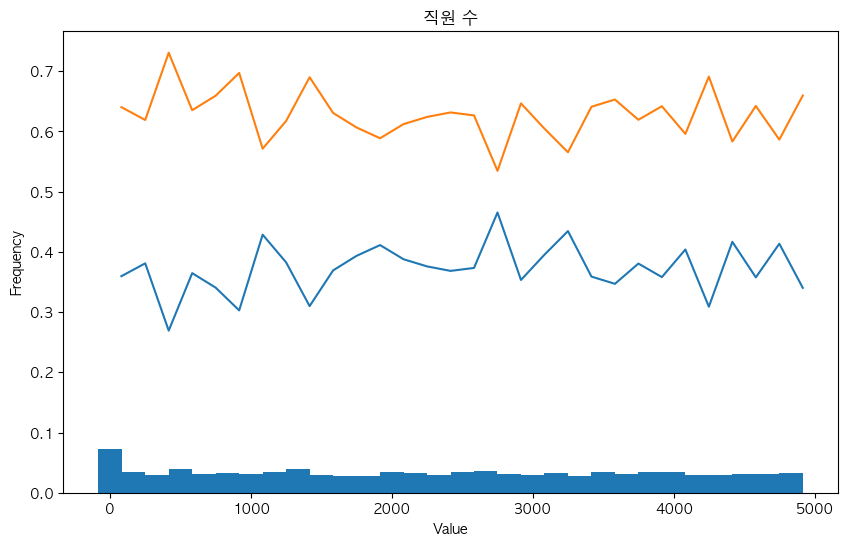

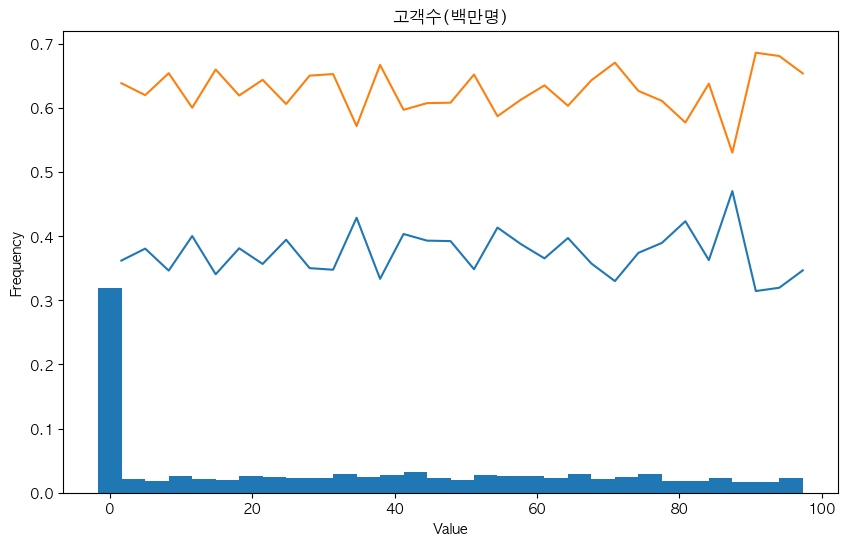

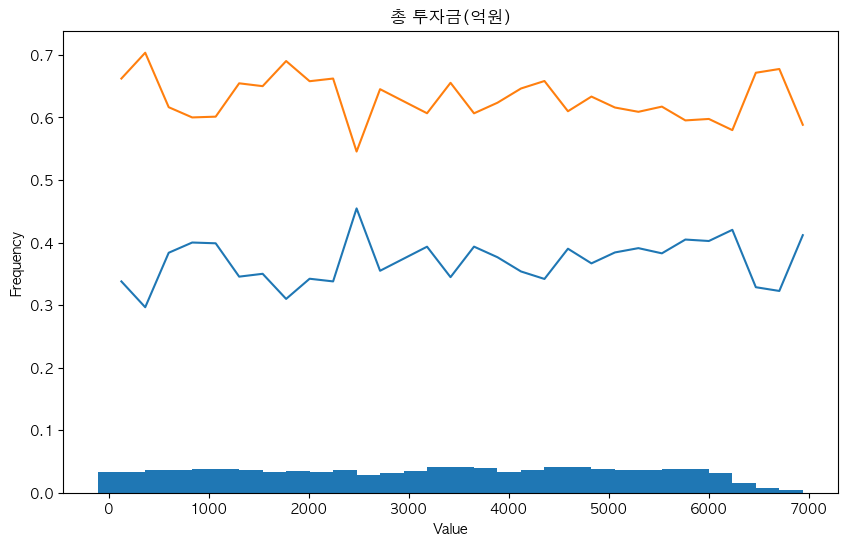

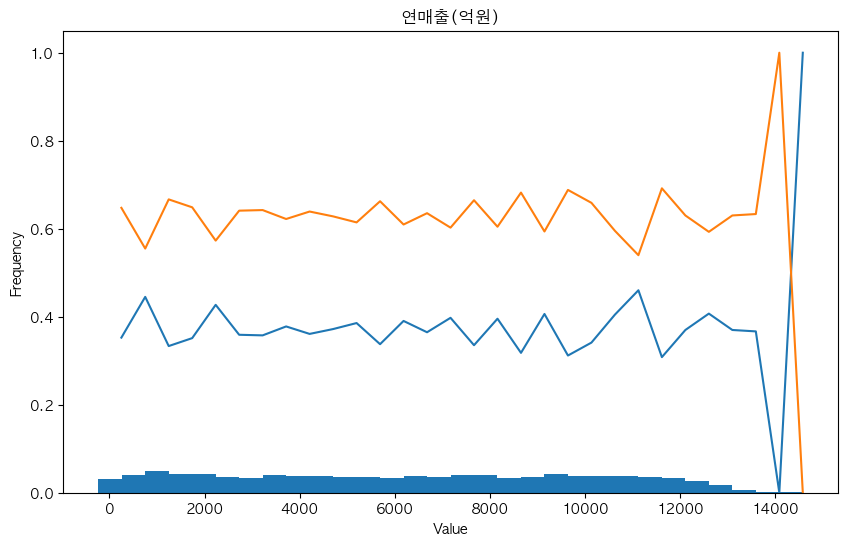

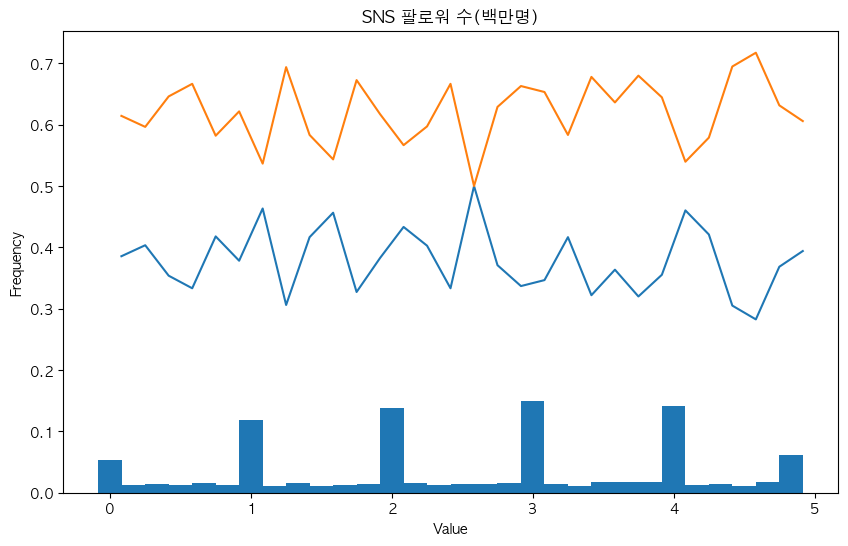

In [64]:
# feature 별 개수 확인 (결측치 제외))

for col in numeric_features:
    train_df=train.copy() #원본 보호
    train_df = train_df.dropna(subset=[col])
    
    train_df['bin']=pd.cut(train_df[col], bins=30)
    
    count_df = train_df.groupby(['bin', '성공확률']).size().unstack(fill_value=0)
    count_df = count_df.div(count_df.sum(axis=1), axis=0)
    
    # 구간 중심값
    count_df['bin_center'] = count_df.index.map(lambda x: x.mid)

    counts, bins = np.histogram(train_df[col], bins=30)
    percent = counts / counts.sum()

    plt.figure(figsize=(10,6))
    
    plt.bar(bins[:-1], percent, width=np.diff(bins))

    count_df['[0,0.5)'] = 0
    count_df['[0.5,1]'] = 0
    for percentage in count_df.columns[:-3]:
        if percentage<0.5: count_df['[0,0.5)']+=count_df[percentage]
        else: count_df['[0.5,1]']+=count_df[percentage]
    plt.plot(count_df['bin_center'], count_df['[0,0.5)'], label=percentage)
    plt.plot(count_df['bin_center'], count_df['[0.5,1]'], label=percentage)
    
    '''for percentage in count_df.columns[:-1]:  # 마지막은 bin_center
        plt.plot(count_df['bin_center'], count_df[percentage], label=percentage)'''
    
    plt.title(col)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

In [37]:
#결측치 땜빵

for feature in numeric_features:
    train[feature] = train[feature].fillna(0)
for feature in category_features:
    train[feature] = train[feature].fillna('Missing')

In [38]:
from sklearn.preprocessing import LabelEncoder

# 설립연도 타입 변환 (int -> object)
train['설립연도'] =train['설립연도'].astype('object')

category_features = ['설립연도','국가','분야','투자단계','기업가치(백억원)']
numeric_features = ['직원 수','고객수(백만명)','총 투자금(억원)','연매출(억원)','SNS 팔로워 수(백만명)']
bool_features = ['인수여부','상장여부']

# LabelEncoder 객체를 각 범주형 feature별로 따로 저장하여 사용
encoders = {}

# 범주형 데이터를 encoding
for feature in category_features:
    encoders[feature] = LabelEncoder()
    train[feature] = train[feature].fillna('Missing')
    train[feature] = encoders[feature].fit_transform(train[feature])

# 불리언 값을 0과 1로 변환 ('Yes' → 1, 'No' → 0 으로 변환)
bool_map = {'Yes': 1, 'No': 0}

for feature in bool_features:
    train[feature] = train[feature].map(bool_map)

# 수치형 변수 결측치를 평균값으로 대체
for feature in numeric_features:
    mean_value = train[feature].mean()
    train[feature] = train[feature].fillna(mean_value)

# TabNet용 범주형 변수 인덱스(cat_idxs) 및 차원(cat_dims) 설정
features = [col for col in train.columns if col != '성공확률']
cat_idxs = [features.index(col) for col in category_features]
cat_dims = [train[col].max() + 1 for col in category_features]

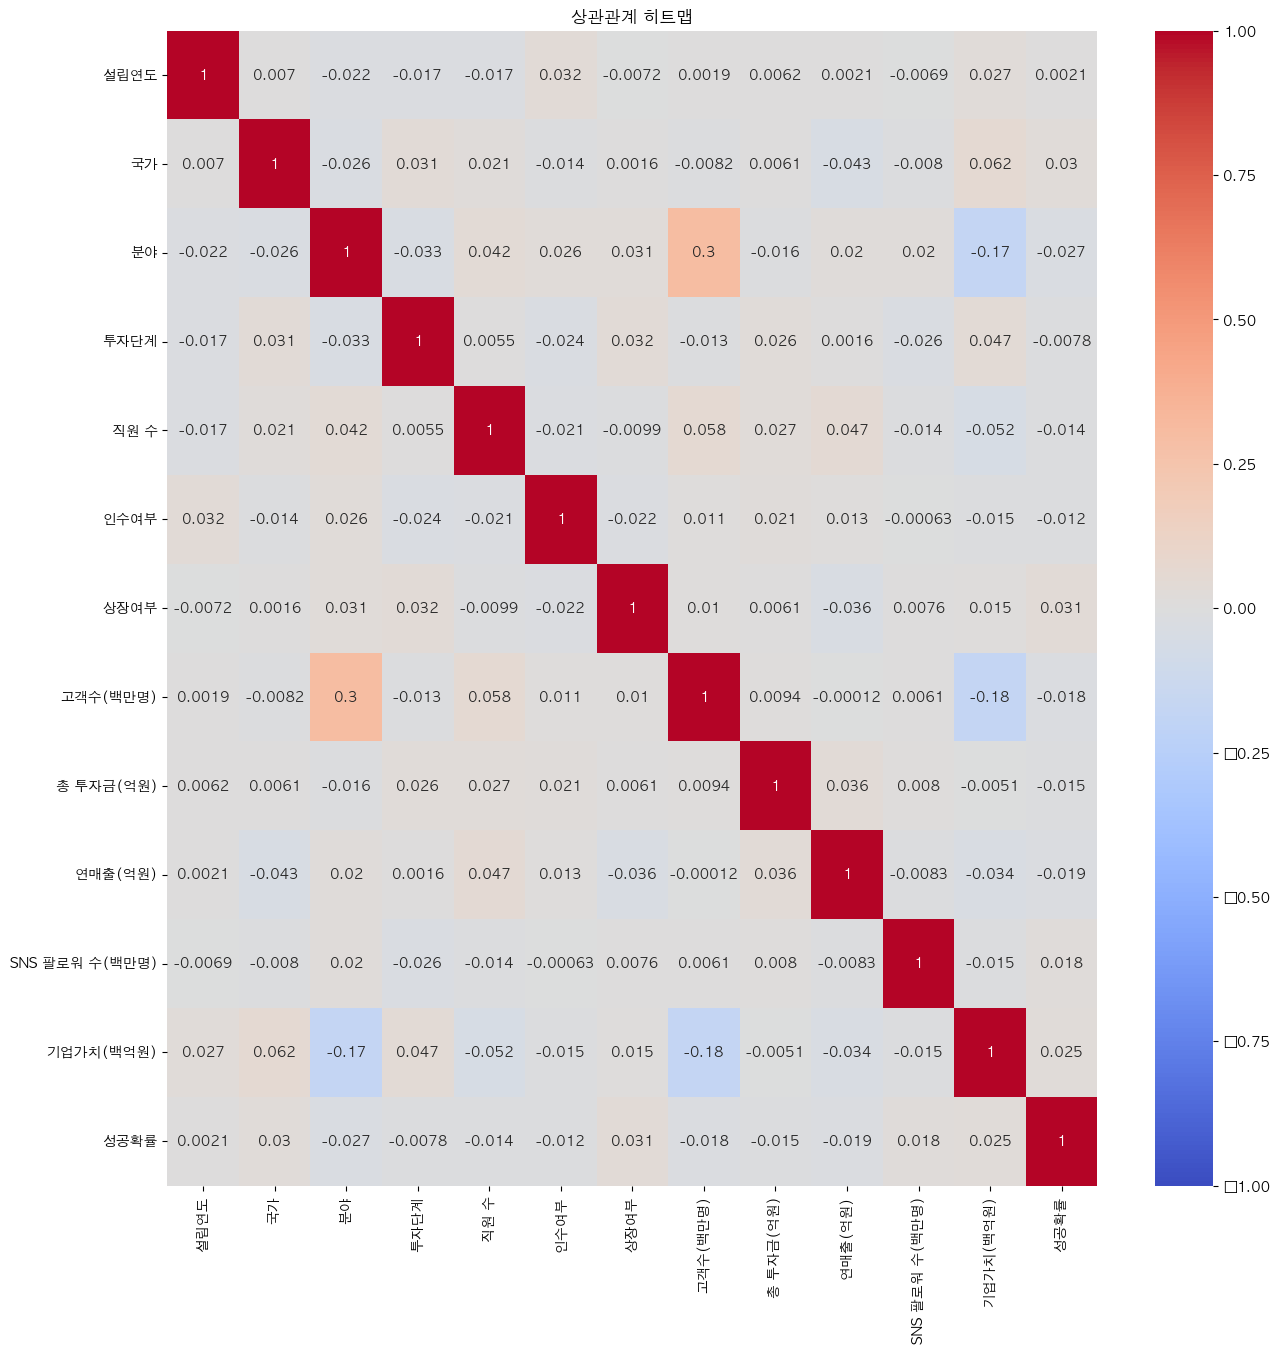

In [39]:
#상관계수
import seaborn as sns

correlation = train.corr(method='pearson')  # method는 'kendall', 'spearman'도 가능
plt.figure(figsize=(15, 15))  # 그래프 크기 조절
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("상관관계 히트맵")
plt.show()

In [40]:
import umap
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import PCA

In [41]:
colors = {
    0.1: '#1f77b4',  # 파랑 (blue)
    0.3: '#ff7f0e',  # 주황 (orange)
    0.4: '#2ca02c',  # 초록 (green)
    0.5: '#d62728',  # 빨강 (red)
    0.6: '#9467bd',  # 보라 (purple)
    0.7: '#8c564b',  # 갈색 (brown)
    0.8: '#e377c2',  # 분홍 (pink)
    0.9: '#7f7f7f',  # 회색 (gray)
}

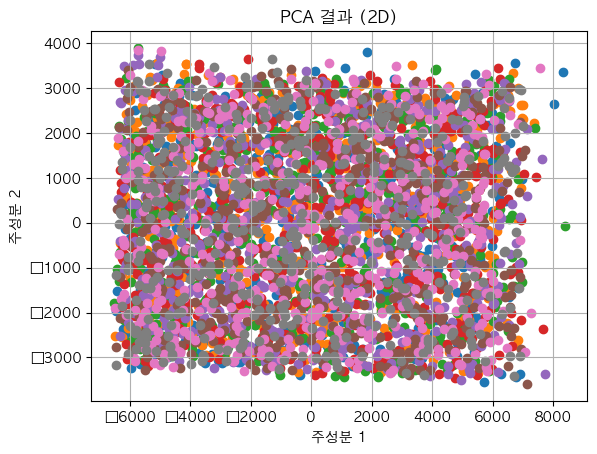

In [42]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(train.drop(columns=['성공확률']))

# 결과를 DataFrame으로 보기 좋게
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['label'] = train['성공확률']


colors = {
    0.1: '#1f77b4',  # 파랑 (blue)
    0.3: '#ff7f0e',  # 주황 (orange)
    0.4: '#2ca02c',  # 초록 (green)
    0.5: '#d62728',  # 빨강 (red)
    0.6: '#9467bd',  # 보라 (purple)
    0.7: '#8c564b',  # 갈색 (brown)
    0.8: '#e377c2',  # 분홍 (pink)
    0.9: '#7f7f7f',  # 회색 (gray)
}

for label in colors:
    subset = pca_df[pca_df['label'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], c=colors[label], label=label)


# 시각화
plt.title("PCA 결과 (2D)")
plt.xlabel("주성분 1")
plt.ylabel("주성분 2")
plt.grid(True)
plt.show()

In [43]:
print(train['성공확률'].unique())

[0.3 0.8 0.5 0.7 0.1 0.6 0.4 0.9]


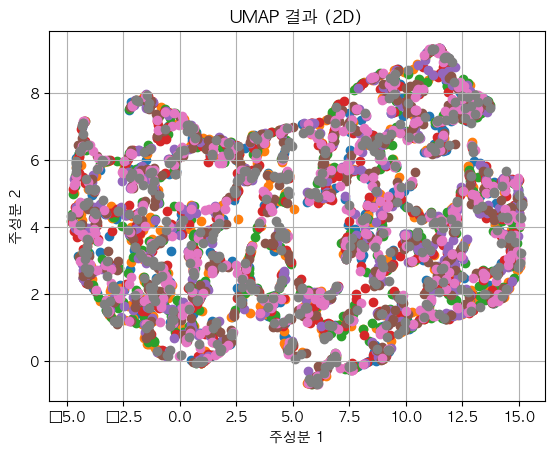

In [44]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(train.drop(columns=['성공확률']))


umap_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
umap_df['label'] = train['성공확률']


colors = {
    0.1: '#1f77b4',  # 파랑 (blue)
    0.3: '#ff7f0e',  # 주황 (orange)
    0.4: '#2ca02c',  # 초록 (green)
    0.5: '#d62728',  # 빨강 (red)
    0.6: '#9467bd',  # 보라 (purple)
    0.7: '#8c564b',  # 갈색 (brown)
    0.8: '#e377c2',  # 분홍 (pink)
    0.9: '#7f7f7f',  # 회색 (gray)
}

for label in colors:
    subset = umap_df[umap_df['label'] == label]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], c=colors[label], label=label)


# 시각화
plt.title("UMAP 결과 (2D)")
plt.xlabel("주성분 1")
plt.ylabel("주성분 2")
plt.grid(True)
plt.show()